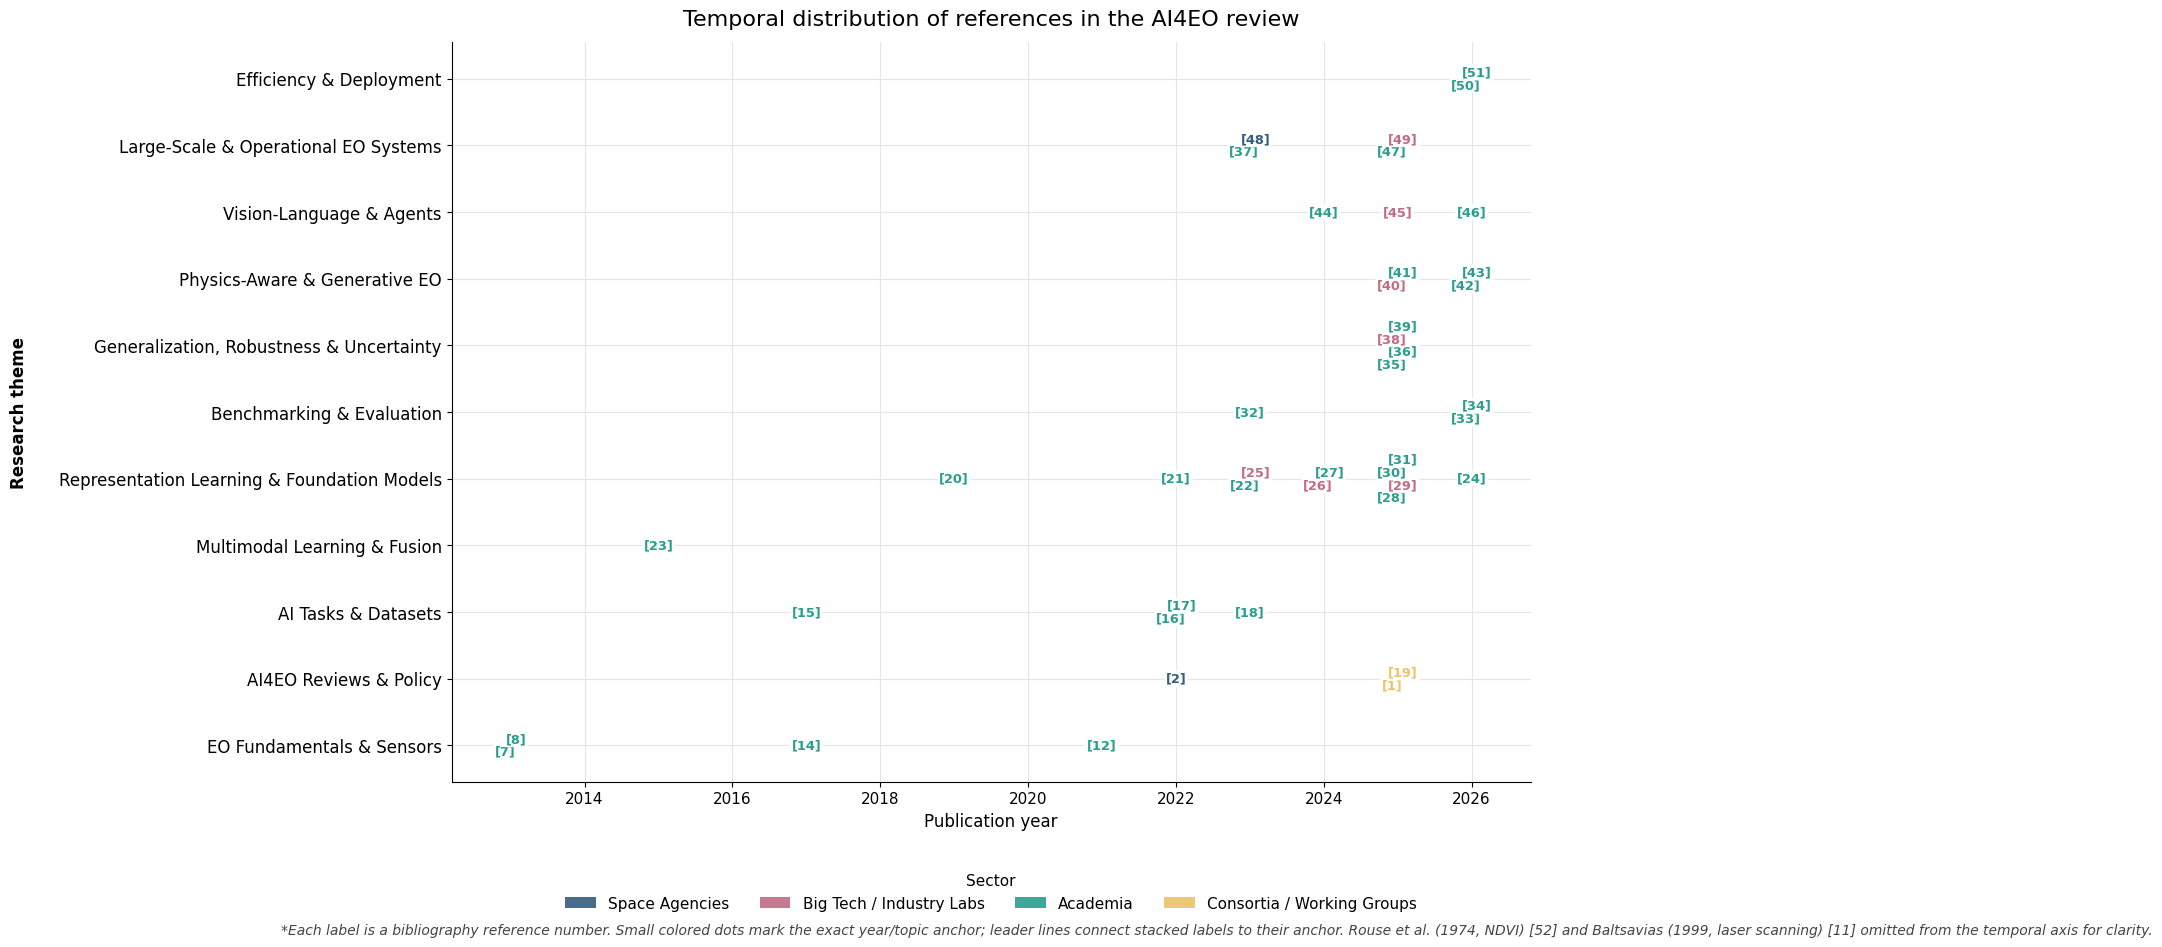

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# DATA
# ============================================================
# Each entry:
# reference number, publication year, topic, sector
#
# [11] Baltsavias (1999) and [52] Rouse et al. (1974)
# are deliberately omitted from the temporal plot.
#
# Undated web/documentation references are also not plotted
# because they do not have a meaningful publication year.

data = [

    # --------------------------------------------------------
    # EO Fundamentals & Sensors
    # --------------------------------------------------------
    (7,  2013, "EO Fundamentals & Sensors", "Academia"),
    (8,  2013, "EO Fundamentals & Sensors", "Academia"),
    (14, 2017, "EO Fundamentals & Sensors", "Academia"),
    (12, 2021, "EO Fundamentals & Sensors", "Academia"),

    # --------------------------------------------------------
    # AI4EO Reviews & Policy
    # --------------------------------------------------------
    (2,  2022, "AI4EO Reviews & Policy", "Space Agencies"),
    (1,  2025, "AI4EO Reviews & Policy", "Consortia / Working Groups"),
    (19, 2025, "AI4EO Reviews & Policy", "Consortia / Working Groups"),

    # --------------------------------------------------------
    # AI Tasks & Datasets
    # --------------------------------------------------------
    (15, 2017, "AI Tasks & Datasets", "Academia"),
    (16, 2022, "AI Tasks & Datasets", "Academia"),
    (17, 2022, "AI Tasks & Datasets", "Academia"),
    (18, 2023, "AI Tasks & Datasets", "Academia"),

    # --------------------------------------------------------
    # Multimodal Learning & Fusion
    # --------------------------------------------------------
    (23, 2015, "Multimodal Learning & Fusion", "Academia"),

    # --------------------------------------------------------
    # Representation Learning & Foundation Models
    # --------------------------------------------------------
    (20, 2019, "Representation Learning & Foundation Models", "Academia"),
    (21, 2022, "Representation Learning & Foundation Models", "Academia"),
    (22, 2023, "Representation Learning & Foundation Models", "Academia"),
    (25, 2023, "Representation Learning & Foundation Models", "Big Tech / Industry Labs"),

    (26, 2024, "Representation Learning & Foundation Models", "Big Tech / Industry Labs"),
    (27, 2024, "Representation Learning & Foundation Models", "Academia"),

    (28, 2025, "Representation Learning & Foundation Models", "Academia"),
    (29, 2025, "Representation Learning & Foundation Models", "Big Tech / Industry Labs"),
    (30, 2025, "Representation Learning & Foundation Models", "Academia"),
    (31, 2025, "Representation Learning & Foundation Models", "Academia"),

    (24, 2026, "Representation Learning & Foundation Models", "Academia"),

    # --------------------------------------------------------
    # Benchmarking & Evaluation
    # --------------------------------------------------------
    (32, 2023, "Benchmarking & Evaluation", "Academia"),
    (33, 2026, "Benchmarking & Evaluation", "Academia"),
    (34, 2026, "Benchmarking & Evaluation", "Academia"),

    # --------------------------------------------------------
    # Generalization, Robustness & Uncertainty
    # --------------------------------------------------------
    (35, 2025, "Generalization, Robustness & Uncertainty", "Academia"),
    (36, 2025, "Generalization, Robustness & Uncertainty", "Academia"),
    (38, 2025, "Generalization, Robustness & Uncertainty", "Big Tech / Industry Labs"),
    (39, 2025, "Generalization, Robustness & Uncertainty", "Academia"),

    # --------------------------------------------------------
    # Physics-Aware & Generative EO
    # --------------------------------------------------------
    (40, 2025, "Physics-Aware & Generative EO", "Big Tech / Industry Labs"),
    (41, 2025, "Physics-Aware & Generative EO", "Academia"),
    (42, 2026, "Physics-Aware & Generative EO", "Academia"),
    (43, 2026, "Physics-Aware & Generative EO", "Academia"),

    # --------------------------------------------------------
    # Vision-Language & Agents
    # --------------------------------------------------------
    (44, 2024, "Vision-Language & Agents", "Academia"),
    (45, 2025, "Vision-Language & Agents", "Big Tech / Industry Labs"),
    (46, 2026, "Vision-Language & Agents", "Academia"),

    # --------------------------------------------------------
    # Large-Scale & Operational EO Systems
    # --------------------------------------------------------
    (37, 2023, "Large-Scale & Operational EO Systems", "Academia"),
    (48, 2023, "Large-Scale & Operational EO Systems", "Space Agencies"),

    (47, 2025, "Large-Scale & Operational EO Systems", "Academia"),
    (49, 2025, "Large-Scale & Operational EO Systems", "Big Tech / Industry Labs"),

    # --------------------------------------------------------
    # Efficiency & Deployment
    # --------------------------------------------------------
    (50, 2026, "Efficiency & Deployment", "Academia"),
    (51, 2026, "Efficiency & Deployment", "Academia"),
]


df = pd.DataFrame(
    data,
    columns=[
        "ref_id",
        "year",
        "topic",
        "sector"
    ]
)


# ============================================================
# TOPIC ORDER
# ============================================================

topic_order = [
    "EO Fundamentals & Sensors",
    "AI4EO Reviews & Policy",
    "AI Tasks & Datasets",
    "Multimodal Learning & Fusion",
    "Representation Learning & Foundation Models",
    "Benchmarking & Evaluation",
    "Generalization, Robustness & Uncertainty",
    "Physics-Aware & Generative EO",
    "Vision-Language & Agents",
    "Large-Scale & Operational EO Systems",
    "Efficiency & Deployment",
]

topic_y = {
    topic: i
    for i, topic in enumerate(topic_order)
}


# ============================================================
# EXACT ANCHOR LOCATIONS
# ============================================================

df["x_anchor"] = df["year"].astype(float)

df["y_anchor"] = (
    df["topic"]
    .map(topic_y)
    .astype(float)
)

df["x_text"] = df["x_anchor"]
df["y_text"] = df["y_anchor"]


# ============================================================
# LABEL STACKING
# ============================================================
# If several references have the same year AND topic,
# spread their labels vertically around the true location.

VERTICAL_STEP = 0.19


for (topic_name, year), idxs in df.groupby(
    ["topic", "year"]
).groups.items():

    idxs = sorted(
        list(idxs),
        key=lambda k: int(df.loc[k, "ref_id"])
    )

    n = len(idxs)

    offsets = [
        (i - (n - 1) / 2) * VERTICAL_STEP
        for i in range(n)
    ]

    for i, (k, dy) in enumerate(
        zip(idxs, offsets)
    ):

        if n == 1:
            dx = 0.0

        else:
            # Alternate slightly left and right
            # around the actual publication year.
            dx = (
                -0.075
                if i % 2 == 0
                else 0.075
            )

        df.loc[k, "x_text"] = (
            df.loc[k, "x_anchor"] + dx
        )

        df.loc[k, "y_text"] = (
            df.loc[k, "y_anchor"] + dy
        )


# ============================================================
# COLORS
# ============================================================

colors = {

    "Space Agencies":
        "#355C7D",

    "Big Tech / Industry Labs":
        "#C06C84",

    "Academia":
        "#2A9D8F",

    "Consortia / Working Groups":
        "#E9C46A",
}


sector_order = [
    "Space Agencies",
    "Big Tech / Industry Labs",
    "Academia",
    "Consortia / Working Groups",
]


# ============================================================
# MATPLOTLIB STYLE
# ============================================================

plt.rcParams.update({

    "font.family":
        "DejaVu Sans",

    "font.size":
        11,

    "axes.titlesize":
        16,

    "axes.labelsize":
        12,

    "xtick.labelsize":
        11,

    "ytick.labelsize":
        12,

    "axes.spines.top":
        False,

    "axes.spines.right":
        False,
})


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(14.2, 10.0)
)


# ============================================================
# ANCHOR DOTS
# ============================================================

for sec in sector_order:

    sub = df[
        df["sector"] == sec
    ]

    ax.scatter(

        sub["x_anchor"],
        sub["y_anchor"],

        s=24,

        c=colors[sec],

        alpha=0.55,

        edgecolors="white",

        linewidths=0.5,

        zorder=3,
    )


# ============================================================
# LEADER LINES
# ============================================================

for _, r in df.iterrows():

    displaced = (

        abs(
            r["x_text"]
            - r["x_anchor"]
        ) > 1e-9

        or

        abs(
            r["y_text"]
            - r["y_anchor"]
        ) > 1e-9
    )

    if displaced:

        ax.plot(

            [
                r["x_anchor"],
                r["x_text"]
            ],

            [
                r["y_anchor"],
                r["y_text"]
            ],

            color="#9A9A9A",

            lw=0.65,

            alpha=0.8,

            zorder=2,
        )


# ============================================================
# REFERENCE NUMBERS
# ============================================================

for _, r in df.iterrows():

    ax.text(

        r["x_text"],
        r["y_text"],

        f"[{int(r['ref_id'])}]",

        color=colors[
            r["sector"]
        ],

        fontsize=9.4,

        fontweight="semibold",

        ha="center",

        va="center",

        zorder=5,

        bbox=dict(

            boxstyle=
                "round,pad=0.13",

            facecolor=
                "white",

            edgecolor=
                "none",

            alpha=
                0.93,
        ),
    )


# ============================================================
# AXES
# ============================================================

xmin = (
    int(df["year"].min())
    - 0.8
)

xmax = (
    int(df["year"].max())
    + 0.8
)


ax.set_xlim(
    xmin,
    xmax
)


ax.set_ylim(
    -0.55,
    len(topic_order) - 0.45
)


ax.set_yticks(
    range(
        len(topic_order)
    )
)


ax.set_yticklabels(
    topic_order
)


ax.set_xlabel(
    "Publication year"
)


ax.set_ylabel(
    "Research theme",
    fontweight="semibold",
    labelpad=22,
)


ax.set_title(
    "Temporal distribution of references in the AI4EO review",
    pad=12,
)


# ============================================================
# GRID
# ============================================================

ax.grid(

    axis="both",

    color="#E5E5E5",

    linewidth=0.8,

    alpha=1.0,

    zorder=0,
)


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    Patch(

        facecolor=
            colors[s],

        edgecolor=
            "none",

        label=s,

        alpha=0.9,
    )

    for s in sector_order
]


ax.legend(

    handles=
        legend_handles,

    ncol=4,

    loc=
        "upper center",

    bbox_to_anchor=
        (0.5, -0.105),

    frameon=
        False,

    title=
        "Sector",
)


# ============================================================
# FOOTNOTE
# ============================================================

fig.text(

    0.10,
    0.028,

    "*Each label is a bibliography reference number. "
    "Small colored dots mark the exact year/topic anchor; "
    "leader lines connect stacked labels to their anchor. "
    "Rouse et al. (1974, NDVI) [52] and "
    "Baltsavias (1999, laser scanning) [11] "
    "omitted from the temporal axis for clarity.",

    fontsize=10,

    style="italic",

    color="#444444",
)


# ============================================================
# MANUAL LAYOUT
# ============================================================

fig.subplots_adjust(

    left=0.22,

    right=0.98,

    top=0.92,

    bottom=0.18,
)


# ============================================================
# SAVE
# ============================================================

fig.savefig(

    "ai4eo_temporal_references.png",

    dpi=350,

    bbox_inches="tight",
)


fig.savefig(

    "ai4eo_temporal_references.pdf",

    bbox_inches="tight",
)


plt.show()